In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

def configurar_entorno_gpu():
    """
    Descripción:
        Verifica y configura la disponibilidad de la GPU en el entorno de ejecución.
    Restricciones:
        Requiere entorno con soporte CUDA (ej. Colab con T4 GPU).
    Entradas:
        Ninguna.
    Salidas:
        Dispositivo configurado (bool).
    """
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"GPU detectada y lista para aceleración: {gpus[0]}")
        return True
    else:
        print("ADVERTENCIA: No se detectó GPU. El proceso de Transfer Learning será excesivamente lento.")
        return False

gpu_lista = configurar_entorno_gpu()

GPU detectada y lista para aceleración: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [2]:
def preparar_datos_crudos(batch_size):
    """
    Descripción:
        Descarga el dataset CIFAR-100 y estructura los pipelines de tf.data.
        Se integra la aumentación de datos espacial.
    Restricciones:
        Los valores de los píxeles se mantienen en el rango [0, 255].
    Entradas:
        - batch_size (int): Tamaño del lote.
    Salidas:
        - train_ds, val_ds, test_ds: Datasets optimizados.
    """
    (x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(label_mode='fine')

    # División 80% entrenamiento, 20% validación
    val_split = int(0.2 * len(x_train_full))
    x_val, y_val = x_train_full[:val_split], y_train_full[:val_split]
    x_train, y_train = x_train_full[val_split:], y_train_full[val_split:]

    AUTOTUNE = tf.data.AUTOTUNE

    # Aumento de datos espacial (las transformaciones de color se evitan para no alterar el preprocesamiento de ImageNet)
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
    ])

    def augment(image, label):
        return data_augmentation(image, training=True), label

    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_ds = train_ds.shuffle(10000).batch(batch_size).map(augment, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(batch_size).prefetch(AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size).prefetch(AUTOTUNE)

    print("Datasets estructurados correctamente.")
    return train_ds, val_ds, test_ds

BATCH_SIZE = 64
train_ds, val_ds, test_ds = preparar_datos_crudos(BATCH_SIZE)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Datasets estructurados correctamente.


In [3]:
def construir_modelo_tl(funcion_modelo_base, funcion_preprocesamiento, resolucion=(128, 128)):
    """
    Descripción:
        Construye un modelo de Transfer Learning integrando redimensionamiento,
        preprocesamiento específico, la base convolucional congelada y una cabeza de clasificación densa.
    Restricciones:
        La base convolucional se inicializa con pesos de ImageNet y se congela en su totalidad.
    Entradas:
        - funcion_modelo_base (callable): Clase del modelo de Keras Applications.
        - funcion_preprocesamiento (callable): Función de preprocesamiento de la familia del modelo.
        - resolucion (tuple): Resolución a la que se escalarán las imágenes de entrada.
    Salidas:
        - modelo (tf.keras.Model): Modelo completo compilado lógicamente.
        - base_model (tf.keras.Model): Referencia a la capa base para su posterior descongelamiento.
    """
    inputs = tf.keras.Input(shape=(32, 32, 3))

    # 1. Redimensionamiento en GPU
    x = layers.Resizing(resolucion[0], resolucion[1])(inputs)

    # 2. Preprocesamiento específico de la arquitectura
    if funcion_preprocesamiento is not None:
        x = funcion_preprocesamiento(x)

    # 3. Base preentrenada (Congelada)
    base_model = funcion_modelo_base(
        weights='imagenet',
        include_top=False,
        input_tensor=x
    )
    base_model.trainable = False

    # 4. Cabeza de clasificación adaptada a CIFAR-100
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(100)(x)

    modelo = tf.keras.Model(inputs, outputs)

    return modelo, base_model

def imprimir_parametros(modelo, nombre):
    """
    Descripción:
        Calcula e imprime el número de parámetros entrenables y no entrenables.
    """
    entrenables = sum([tf.keras.backend.count_params(w) for w in modelo.trainable_weights])
    no_entrenables = sum([tf.keras.backend.count_params(w) for w in modelo.non_trainable_weights])
    print(f"\n--- {nombre} ---")
    print(f"Parámetros Entrenables: {entrenables:,}")
    print(f"Parámetros Congelados: {no_entrenables:,}")

In [4]:
def entrenar_fase_1_congelada(modelo, train_ds, val_ds, epocas, learning_rate=1e-3):
    """
    Descripción:
        Entrena únicamente la nueva cabeza de clasificación agregada al modelo.
    Restricciones:
        La tasa de aprendizaje es moderada/alta para inicializar los pesos aleatorios de la cabeza.
    Entradas:
        - modelo, train_ds, val_ds, epocas, learning_rate.
    Salidas:
        - history_tl: Registro del entrenamiento.
    """
    print("\n--- INICIANDO FASE 1: Transfer Learning (Base Congelada) ---")
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    modelo.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

    history_tl = modelo.fit(train_ds, validation_data=val_ds, epochs=epocas)
    return history_tl

def entrenar_fase_2_finetuning(modelo, base_model, train_ds, val_ds, epocas, capas_a_descongelar=20, learning_rate=1e-5):
    """
    Descripción:
        Descongela las últimas 'N' capas del modelo base y continúa el entrenamiento
        con una tasa de aprendizaje significativamente menor para realizar un ajuste fino.
    Restricciones:
        Debe ejecutarse estrictamente después de la Fase 1 para evitar degradar los pesos preentrenados.
    Entradas:
        - modelo, base_model, train_ds, val_ds, epocas.
        - capas_a_descongelar (int): Número de capas finales del base_model a entrenar.
        - learning_rate (float): Tasa de aprendizaje muy baja (ej. 1e-5).
    Salidas:
        - history_ft: Registro del ajuste fino.
    """
    print(f"\n--- INICIANDO FASE 2: Fine-Tuning (Descongelando {capas_a_descongelar} capas) ---")

    # Descongelar el modelo base
    base_model.trainable = True

    # Congelar todas las capas excepto las últimas indicadas
    for layer in base_model.layers[:-capas_a_descongelar]:
        layer.trainable = False

    # Recompilar el modelo con un LR muy bajo
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    # Uso de Early Stopping en FT para evitar sobreajuste severo
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]

    modelo.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
    imprimir_parametros(modelo, "Estado post-descongelamiento")

    history_ft = modelo.fit(train_ds, validation_data=val_ds, epochs=epocas, callbacks=callbacks)
    return history_ft

# Primera corrida,
### Al final vi que no pasaba el 75% entonces haré otra corrida descongelando mas capas y aumentando las epocas pero solo en el FT

In [5]:
# A) MOBILENETV2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input as prep_mobilenet

EPOCAS_TL = 6
EPOCAS_FT = 8

modelo1, base1 = construir_modelo_tl(MobileNetV2, prep_mobilenet)
imprimir_parametros(modelo1, "MobileNetV2 - Fase TL")

# Ejecución de fases
historial1_tl = entrenar_fase_1_congelada(modelo1, train_ds, val_ds, epocas=EPOCAS_TL)
historial1_ft = entrenar_fase_2_finetuning(modelo1, base1, train_ds, val_ds, epocas=EPOCAS_FT, capas_a_descongelar=30)

# Evaluación
_, test_acc1 = modelo1.evaluate(test_ds, verbose=0)
print(f"Accuracy Final MobileNetV2: {test_acc1 * 100:.2f}%")

/tmp/ipykernel_1772/3362521974.py:26: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = funcion_modelo_base(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- MobileNetV2 - Fase TL ---
Parámetros Entrenables: 130,660
Parámetros Congelados: 2,260,544

--- INICIANDO FASE 1: Transfer Learning (Base Congelada) ---
Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 54ms/step - accuracy: 0.2843 - loss: 3.1914 - val_accuracy: 0.5647 - val_loss: 1.6539
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4053 - loss: 2.4315 - val_accuracy: 0.5921 - val_loss: 1.5431
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.4255 - loss: 2.2972 - val_accuracy: 0.6032 - val_loss: 1.4869
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.4398 - loss: 2.2084 - val_accuracy: 0.6077 - val_loss: 1.4660
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.4468 - loss: 2.1608 - val_accuracy: 0.6097 - val_loss: 1.4465
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4542 - loss: 2.1240 - val_accuracy: 0.6095 - val_loss: 1.4331

--- INICIANDO FASE

In [6]:
# B) ResNet50V2
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input as prep_resnet

modelo2, base2 = construir_modelo_tl(ResNet50V2, prep_resnet)
imprimir_parametros(modelo2, "ResNet50V2 - Fase TL")

# Ejecución de fases
historial2_tl = entrenar_fase_1_congelada(modelo2, train_ds, val_ds, epocas=EPOCAS_TL)
historial2_ft = entrenar_fase_2_finetuning(modelo2, base2, train_ds, val_ds, epocas=EPOCAS_FT, capas_a_descongelar=40)

# Evaluación
_, test_acc2 = modelo2.evaluate(test_ds, verbose=0)
print(f"Accuracy Final ResNet50V2: {test_acc2 * 100:.2f}%")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- ResNet50V2 - Fase TL ---
Parámetros Entrenables: 208,996
Parámetros Congelados: 23,568,896

--- INICIANDO FASE 1: Transfer Learning (Base Congelada) ---
Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 70ms/step - accuracy: 0.2981 - loss: 3.0792 - val_accuracy: 0.5513 - val_loss: 1.6862
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.4068 - loss: 2.4269 - val_accuracy: 0.5821 - val_loss: 1.5793
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.4302 - loss: 2.2786 - val_accuracy: 0.5928 - val_loss: 1.5067
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.4389 - loss: 2.2015 - val_accuracy: 0.5935 - val_loss: 1.4806
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.4489 - loss: 2.1519 - val_accuracy: 0.6057 - val_loss: 1.4405
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.4606 - loss: 2.0878 - val_accuracy: 0.6104 - val_loss: 1.4247

--- INICIANDO FA

In [7]:
#C) EfficientNetB0

from tensorflow.keras.applications import EfficientNetB0
# EfficientNet no usa funcion de preprocesamiento externa en keras
modelo3, base3 = construir_modelo_tl(EfficientNetB0, None)
imprimir_parametros(modelo3, "EfficientNetB0 - Fase TL")

# Ejecución de fases
historial3_tl = entrenar_fase_1_congelada(modelo3, train_ds, val_ds, epocas=EPOCAS_TL)
historial3_ft = entrenar_fase_2_finetuning(modelo3, base3, train_ds, val_ds, epocas=EPOCAS_FT, capas_a_descongelar=20)

# Evaluación
_, test_acc3 = modelo3.evaluate(test_ds, verbose=0)
print(f"Accuracy Final EfficientNetB0: {test_acc3 * 100:.2f}%")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- EfficientNetB0 - Fase TL ---
Parámetros Entrenables: 130,660
Parámetros Congelados: 4,052,131.0

--- INICIANDO FASE 1: Transfer Learning (Base Congelada) ---
Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 55ms/step - accuracy: 0.3182 - loss: 3.0305 - val_accuracy: 0.6211 - val_loss: 1.3822
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.4329 - loss: 2.2968 - val_accuracy: 0.6429 - val_loss: 1.2829
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4627 - loss: 2.1184 - val_accuracy: 0.6529 - val_loss: 1.2449
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.4751 - loss: 2.0444 - val_accuracy: 0.6621 - val_loss: 1.2101
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4881 - loss: 1.9945 - val_accuracy: 0.6613 - val_loss: 1.1956
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4902 - loss: 1.9660 - val_accuracy: 0.6624 - val_loss: 1.1942

--- INICIAN

In [8]:
def extraer_metricas_finales(hist_tl, hist_ft):
    """
    Descripción:
        Combina los historiales de TL y FT para extraer el mejor accuracy
        obtenido a lo largo de todo el proceso de entrenamiento.
    """
    acc_train = max(max(hist_tl.history['accuracy']), max(hist_ft.history['accuracy'])) * 100
    acc_val = max(max(hist_tl.history['val_accuracy']), max(hist_ft.history['val_accuracy'])) * 100
    return acc_train, acc_val

# Compilación de resultados
resultados_tl = []
modelos_lista = [modelo1, modelo2, modelo3]
nombres_tl = ["TL/FT 1 (MobileNetV2)", "TL/FT 2 (ResNet50V2)", "TL/FT 3 (EfficientNetB0)"]
historiales_tl = [historial1_tl, historial2_tl, historial3_tl]
historiales_ft = [historial1_ft, historial2_ft, historial3_ft]
test_accs = [test_acc1, test_acc2, test_acc3]

for mod, nombre, h_tl, h_ft, t_acc in zip(modelos_lista, nombres_tl, historiales_tl, historiales_ft, test_accs):
    acc_train, acc_val = extraer_metricas_finales(h_tl, h_ft)

    resultados_tl.append({
        "Modelo": nombre,
        "Acc. Train (%)": f"{acc_train:.2f}",
        "Acc. Val (%)": f"{acc_val:.2f}",
        "Acc. Test (%)": f"{t_acc * 100:.2f}",
        "¿Supera 75%?": "Sí" if (t_acc * 100) >= 75.0 else "No"
    })

df_resultados_tl = pd.DataFrame(resultados_tl)

print("\n" + "="*70)
print("COMPARACIÓN FINAL DE MODELOS TRANSFER LEARNING & FINE-TUNING")
print("="*70)
print(df_resultados_tl.to_string(index=False))


COMPARACIÓN FINAL DE MODELOS TRANSFER LEARNING & FINE-TUNING
                  Modelo Acc. Train (%) Acc. Val (%) Acc. Test (%) ¿Supera 75%?
   TL/FT 1 (MobileNetV2)          51.72        63.93         63.12           No
    TL/FT 2 (ResNet50V2)          57.18        67.10         67.08           No
TL/FT 3 (EfficientNetB0)          51.35        68.04         68.10           No


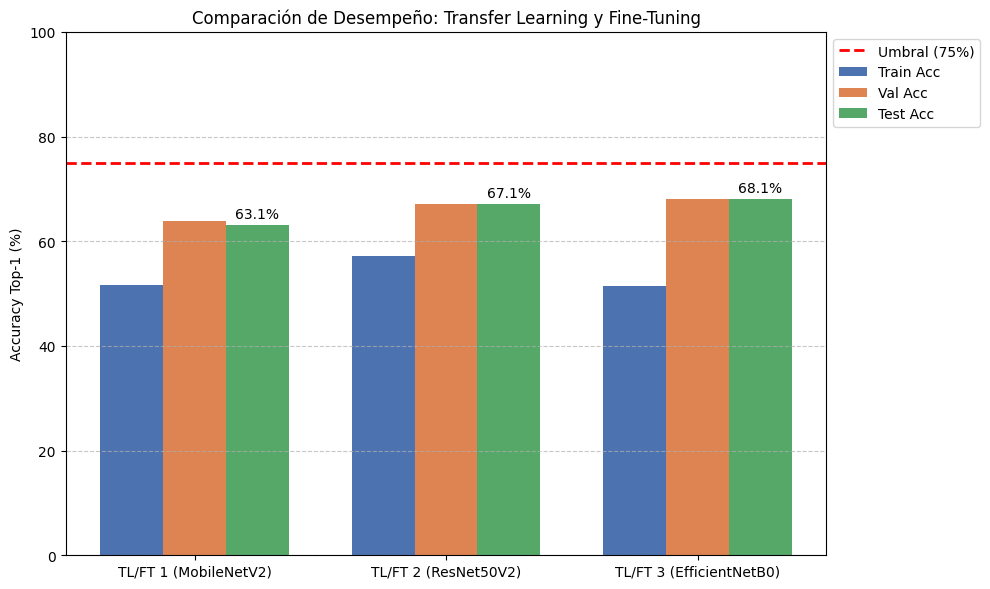

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def graficar_comparacion_tl(df):
    """
    Descripción:
        Genera un gráfico de barras agrupadas comparando las métricas de
        Entrenamiento, Validación y Prueba de los modelos preentrenados evaluados,
        incluyendo la línea de umbral correspondiente a la segunda tarea.

    Restricciones:
        Requiere el DataFrame generado en la celda anterior (df_resultados_tl).

    Entradas:
        - df (pd.DataFrame): Tabla con las métricas finales consolidadas.

    Salidas:
        Ninguna (Despliega la gráfica en la interfaz).
    """
    train_acc = df['Acc. Train (%)'].astype(float)
    val_acc = df['Acc. Val (%)'].astype(float)
    test_acc = df['Acc. Test (%)'].astype(float)

    # Se actualiza la llave para coincidir con la tabla de TL/FT
    nombres = df['Modelo']

    x = np.arange(len(nombres))
    width = 0.25  # Ancho de las barras

    fig, ax = plt.subplots(figsize=(10, 6))

    # Dibujar las barras para cada métrica
    rects1 = ax.bar(x - width, train_acc, width, label='Train Acc', color='#4C72B0')
    rects2 = ax.bar(x, val_acc, width, label='Val Acc', color='#DD8452')
    rects3 = ax.bar(x + width, test_acc, width, label='Test Acc', color='#55A868')

    # Línea del umbral actualizada al 75%
    ax.axhline(y=75.0, color='r', linestyle='--', linewidth=2, label='Umbral (75%)')

    # Etiquetas y diseño actualizados
    ax.set_ylabel('Accuracy Top-1 (%)')
    ax.set_title('Comparación de Desempeño: Transfer Learning y Fine-Tuning')
    ax.set_xticks(x)
    ax.set_xticklabels(nombres)
    ax.set_ylim(0, 100) # El eje Y va de 0 a 100%
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Agregar los números encima de la barra de 'Test'
    ax.bar_label(rects3, padding=3, fmt='%.1f%%')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Ejecutar la gráfica usando la tabla de resultados de TL
graficar_comparacion_tl(df_resultados_tl)

# Segunda corrida con datos modificados
### Como no pude pasar del 75% en entrenamiento entonces modifífco las épocas del FT y la cantidad de capas descongeladas, pero solo de los modelos "B) ResNet50V2" y "C) EfficientNetB0"






In [14]:
# Configuración de épocas para el ajuste fino
EPOCAS_FT = 16

def reconstruir_log_entrenamiento(historial, nombre_fase):
    """
    Descripción:
        Extrae las métricas almacenadas en un objeto History de Keras y
        reconstruye visualmente el log de entrenamiento época por época.
    Restricciones:
        El historial no almacena los tiempos de ejecución por paso, por lo
        que esa sección se omite en la reconstrucción visual.
    Entradas:
        - historial: Objeto History de Keras en memoria.
        - nombre_fase (str): Título para el bloque de texto.
    Salidas:
        Ninguna (Imprime el log en consola).
    """
    print(f"\n--- {nombre_fase} ---")

    acc = historial.history['accuracy']
    loss = historial.history['loss']
    val_acc = historial.history['val_accuracy']
    val_loss = historial.history['val_loss']

    total_epocas = len(acc)

    for i in range(total_epocas):
        print(f"Epoch {i+1}/{total_epocas} ━━━━━━━━━━━━━━━━━━━━ - accuracy: {acc[i]:.4f} - loss: {loss[i]:.4f} - val_accuracy: {val_acc[i]:.4f} - val_loss: {val_loss[i]:.4f}")

# ==========================================
# EJECUCIÓN MODELO 1: MobileNetV2
# ==========================================
print("\n" + "="*60)
print("PROCESO COMPLETO: MobileNetV2")
print("="*60)

# 1. Imprimir la evolución de la Fase 1 rescatada de la variable
reconstruir_log_entrenamiento(historial1_tl, "INICIANDO FASE 1: Transfer Learning (Base Congelada)")

# 2. Ejecutar la Fase 2 (Fine-Tuning) que se imprimirá sola automáticamente
print("\n--- INICIANDO FASE 2: Fine-Tuning (Descongelando 50 capas) ---")
historial1_ft = entrenar_fase_2_finetuning(modelo1, base1, train_ds, val_ds, epocas=EPOCAS_FT, capas_a_descongelar=50)

# NOTA, SALE UN EROR PORUQE INTENTE CORRER LA CELDA SIN HABER CORRIDO ANTES OTRA CON UNA FUNCIÓN PREVIA, PERO COMO SE TARDA BASTANTE EN CORRER PARA ESTAS CELDAS DE ENTRENAMEINTO ENTONCES YA NO LA VOLVI A CORRER Y SOLO EXTRAJE LOS DATOS CRUDOS



PROCESO COMPLETO: MobileNetV2

--- INICIANDO FASE 1: Transfer Learning (Base Congelada) ---
Epoch 1/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.2843 - loss: 3.1914 - val_accuracy: 0.5647 - val_loss: 1.6539
Epoch 2/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4053 - loss: 2.4315 - val_accuracy: 0.5921 - val_loss: 1.5431
Epoch 3/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4255 - loss: 2.2972 - val_accuracy: 0.6032 - val_loss: 1.4869
Epoch 4/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4398 - loss: 2.2084 - val_accuracy: 0.6077 - val_loss: 1.4660
Epoch 5/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4468 - loss: 2.1608 - val_accuracy: 0.6097 - val_loss: 1.4465
Epoch 6/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4542 - loss: 2.1240 - val_accuracy: 0.6095 - val_loss: 1.4331

--- INICIANDO FASE 2: Fine-Tuning (Descongelando 50 capas) ---

--- INICIANDO FASE 2: Fine-Tuning (Descongelando 50 capas) ---

--- Estado post-descongelamiento ---
Parámetros Entrenables: 1,657,060
Parámetros Congelados: 734,144
Epoch 1/16
625/625 ━━━━━━━━━━━━━━━

NameError: name 'graficar_historial_completo' is not defined

In [15]:

# ==========================================
# EJECUCIÓN MODELO 2: ResNet50V2
# ==========================================
print("\n" + "="*60)
print("PROCESO COMPLETO: ResNet50V2")
print("="*60)

reconstruir_log_entrenamiento(historial2_tl, "INICIANDO FASE 1: Transfer Learning (Base Congelada)")
print("\n--- INICIANDO FASE 2: Fine-Tuning (Descongelando 70 capas) ---")
historial2_ft_v2 = entrenar_fase_2_finetuning(modelo2, base2, train_ds, val_ds, epocas=EPOCAS_FT, capas_a_descongelar=70)


# NOTA, SALE UN EROR PORUQE INTENTE CORRER LA CELDA SIN HABER CORRIDO ANTES OTRA CON UNA FUNCIÓN PREVIA, PERO COMO SE TARDA BASTANTE EN CORRER PARA ESTAS CELDAS DE ENTRENAMEINTO ENTONCES YA NO LA VOLVI A CORRER Y SOLO EXTRAJE LOS DATOS CRUDOS


PROCESO COMPLETO: ResNet50V2

--- INICIANDO FASE 1: Transfer Learning (Base Congelada) ---
Epoch 1/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.2981 - loss: 3.0792 - val_accuracy: 0.5513 - val_loss: 1.6862
Epoch 2/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4068 - loss: 2.4269 - val_accuracy: 0.5821 - val_loss: 1.5793
Epoch 3/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4302 - loss: 2.2786 - val_accuracy: 0.5928 - val_loss: 1.5067
Epoch 4/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4389 - loss: 2.2015 - val_accuracy: 0.5935 - val_loss: 1.4806
Epoch 5/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4489 - loss: 2.1519 - val_accuracy: 0.6057 - val_loss: 1.4405
Epoch 6/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4606 - loss: 2.0878 - val_accuracy: 0.6104 - val_loss: 1.4247

--- INICIANDO FASE 2: Fine-Tuning (Descongelando 70 capas) ---

--- INICIANDO FASE 2: Fine-Tuning (Descongelando 70 capas) ---

--- Estado post-descongelamiento ---
Parámetros Entrenables: 15,443,044
Parámetros Congelados: 8,334,848
Epoch 1/16
625/625 ━━━━━━━━━━━━━

NameError: name 'graficar_historial_completo' is not defined

In [16]:
EPOCAS_FT = 16
# ==========================================
# EJECUCIÓN MODELO 3: EfficientNetB0
# ==========================================
print("\n" + "="*60)
print("PROCESO COMPLETO: EfficientNetB0")
print("="*60)

reconstruir_log_entrenamiento(historial3_tl, "INICIANDO FASE 1: Transfer Learning (Base Congelada)")
print("\n--- INICIANDO FASE 2: Fine-Tuning (Descongelando 40 capas) ---")
historial3_ft_v2 = entrenar_fase_2_finetuning(
    modelo3,
    base3,
    train_ds,
    val_ds,
    epocas=EPOCAS_FT,
    capas_a_descongelar=40)





PROCESO COMPLETO: EfficientNetB0

--- INICIANDO FASE 1: Transfer Learning (Base Congelada) ---
Epoch 1/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.3182 - loss: 3.0305 - val_accuracy: 0.6211 - val_loss: 1.3822
Epoch 2/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4329 - loss: 2.2968 - val_accuracy: 0.6429 - val_loss: 1.2829
Epoch 3/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4627 - loss: 2.1184 - val_accuracy: 0.6529 - val_loss: 1.2449
Epoch 4/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4751 - loss: 2.0444 - val_accuracy: 0.6621 - val_loss: 1.2101
Epoch 5/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4881 - loss: 1.9945 - val_accuracy: 0.6613 - val_loss: 1.1956
Epoch 6/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4902 - loss: 1.9660 - val_accuracy: 0.6624 - val_loss: 1.1942

--- INICIANDO FASE 2: Fine-Tuning (Descongelando 40 capas) ---

--- INICIANDO FASE 2: Fine-Tuning (Descongelando 40 capas) ---

--- Estado post-descongelamiento ---
Parámetros Entrenables: 1,481,620
Parámetros Congelados: 2,701,171.0
Epoch 1/16
625/625 ━━━━━━━━

Evaluando conjuntos de prueba...

RESULTADOS DE LOS INTENTOS DE FINE-TUNING ESTÁNDAR
                        Modelo  Acc. Train (%)  Acc. Val (%)  Acc. Test (%)
   MobileNetV2\n(Descongelado)           59.41         68.25          67.61
    ResNet50V2\n(Descongelado)           69.67         71.29          70.83
EfficientNetB0\n(Descongelado)           57.26         70.75          75.68

Generando gráfica...


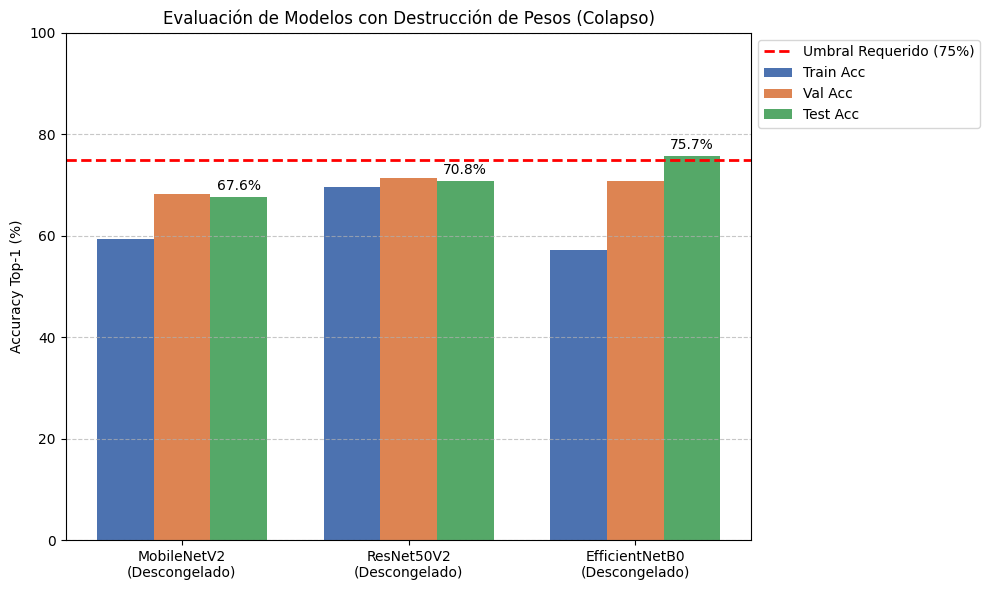

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extraer_metricas_maximas(hist_tl, hist_ft):
    """
    Descripción:
        Combina los historiales de la fase congelada y el fine-tuning
        para extraer el valor máximo alcanzado en entrenamiento y validación.
    """
    acc_train = max(max(hist_tl.history['accuracy']), max(hist_ft.history['accuracy'])) * 100
    acc_val = max(max(hist_tl.history['val_accuracy']), max(hist_ft.history['val_accuracy'])) * 100
    return acc_train, acc_val

# 1. Evaluar el conjunto de prueba para los tres modelos en memoria
print("Evaluando conjuntos de prueba...")
_, test_acc1 = modelo1.evaluate(test_ds, verbose=0)
_, test_acc2 = modelo2.evaluate(test_ds, verbose=0)
_, test_acc3 = modelo3.evaluate(test_ds, verbose=0)

# 2. Extraer métricas usando las variables exactas de tu ejecución
acc_train1, acc_val1 = extraer_metricas_maximas(historial1_tl, historial1_ft)
acc_train2, acc_val2 = extraer_metricas_maximas(historial2_tl, historial2_ft_v2)
acc_train3, acc_val3 = extraer_metricas_maximas(historial3_tl, historial3_ft_v2)

# 3. Construir DataFrame
datos_fallidos = [
    {"Modelo": "MobileNetV2\n(Descongelado)", "Acc. Train (%)": acc_train1, "Acc. Val (%)": acc_val1, "Acc. Test (%)": test_acc1 * 100},
    {"Modelo": "ResNet50V2\n(Descongelado)", "Acc. Train (%)": acc_train2, "Acc. Val (%)": acc_val2, "Acc. Test (%)": test_acc2 * 100},
    {"Modelo": "EfficientNetB0\n(Descongelado)", "Acc. Train (%)": acc_train3, "Acc. Val (%)": acc_val3, "Acc. Test (%)": test_acc3 * 100}
]

df_fallidos = pd.DataFrame(datos_fallidos)

# 4. Función de Graficado
def graficar_comparacion_fallidos(df):
    """
    Descripción:
        Genera un gráfico de barras agrupadas demostrando el estancamiento
        de los modelos frente al umbral del 75%.
    """
    train_acc = df['Acc. Train (%)'].astype(float)
    val_acc = df['Acc. Val (%)'].astype(float)
    test_acc = df['Acc. Test (%)'].astype(float)
    nombres = df['Modelo']

    x = np.arange(len(nombres))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    # Barras
    rects1 = ax.bar(x - width, train_acc, width, label='Train Acc', color='#4C72B0')
    rects2 = ax.bar(x, val_acc, width, label='Val Acc', color='#DD8452')
    rects3 = ax.bar(x + width, test_acc, width, label='Test Acc', color='#55A868')

    # Línea del umbral a superar
    ax.axhline(y=75.0, color='r', linestyle='--', linewidth=2, label='Umbral Requerido (75%)')

    # Diseño
    ax.set_ylabel('Accuracy Top-1 (%)')
    ax.set_title('Evaluación de Modelos con Destrucción de Pesos (Colapso)')
    ax.set_xticks(x)
    ax.set_xticklabels(nombres)
    ax.set_ylim(0, 100)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Etiquetas de texto sobre la barra de prueba
    ax.bar_label(rects3, padding=3, fmt='%.1f%%')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 5. Ejecutar la gráfica
print("\n" + "="*60)
print("RESULTADOS DE LOS INTENTOS DE FINE-TUNING ESTÁNDAR")
print("="*60)
print(df_fallidos.round(2).to_string(index=False))
print("\nGenerando gráfica...")
graficar_comparacion_fallidos(df_fallidos)

# Tercera Corrida
### Como de nuevo ninguna supero el 75 entonces hice modificaciones pero solo al tercer modelo

In [17]:
EPOCAS_FT = 30

print("\n" + "="*60)
print("PROCESO COMPLETO: EfficientNetB0")
print("="*60)

# 1. Mostrar la evolución previa
reconstruir_log_entrenamiento(historial3_tl, "INICIANDO FASE 1: Transfer Learning (Base Congelada)")

print("\n--- INICIANDO FASE 2: Fine-Tuning (Descongelando 100 capas) ---")
# 2. Ejecutar Fase 2 con parámetros agresivos pero controlados
historial3_ft_v3 = entrenar_fase_2_finetuning(
    modelo3,
    base3,
    train_ds,
    val_ds,
    epocas=EPOCAS_FT,
    capas_a_descongelar=100,
    learning_rate=5e-5 # Tasa de aprendizaje ligeramente incrementada
)




PROCESO COMPLETO: EfficientNetB0

--- INICIANDO FASE 1: Transfer Learning (Base Congelada) ---
Epoch 1/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.3182 - loss: 3.0305 - val_accuracy: 0.6211 - val_loss: 1.3822
Epoch 2/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4329 - loss: 2.2968 - val_accuracy: 0.6429 - val_loss: 1.2829
Epoch 3/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4627 - loss: 2.1184 - val_accuracy: 0.6529 - val_loss: 1.2449
Epoch 4/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4751 - loss: 2.0444 - val_accuracy: 0.6621 - val_loss: 1.2101
Epoch 5/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4881 - loss: 1.9945 - val_accuracy: 0.6613 - val_loss: 1.1956
Epoch 6/6 ━━━━━━━━━━━━━━━━━━━━ - accuracy: 0.4902 - loss: 1.9660 - val_accuracy: 0.6624 - val_loss: 1.1942

--- INICIANDO FASE 2: Fine-Tuning (Descongelando 100 capas) ---

--- INICIANDO FASE 2: Fine-Tuning (Descongelando 100 capas) ---

--- Estado post-descongelamiento ---
Parámetros Entrenables: 1,481,620
Parámetros Congelados: 2,701,171.0
Epoch 1/30
625/625 ━━━━━━

In [18]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

print("--- CONSTRUYENDO MODELO EFFICIENTNET DEFINITIVO (PROTEGIDO) ---")

# 1. Aumento de resolución a 160x160
inputs_protegido = tf.keras.Input(shape=(32, 32, 3))
x_prot = layers.Resizing(160, 160)(inputs_protegido)

# 2. Base Model congelada asignada a una nueva variable
base3_protegida = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x_prot)
base3_protegida.trainable = False

# 3. Cabeza de clasificación optimizada
x_prot = base3_protegida.output
x_prot = layers.GlobalAveragePooling2D()(x_prot)
x_prot = layers.BatchNormalization()(x_prot)
x_prot = layers.Dropout(0.3)(x_prot)
outputs_protegido = layers.Dense(100)(x_prot)

modelo3_protegido = tf.keras.Model(inputs_protegido, outputs_protegido)

# ==========================================
# FASE 1: TRANSFER LEARNING (Cabeza)
# ==========================================
print("\n--- FASE 1: Entrenando cabeza de clasificación en 160x160 (5 Épocas) ---")
modelo3_protegido.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Historial independiente para la fase 1
historial3_tl_protegido = modelo3_protegido.fit(train_ds, validation_data=val_ds, epochs=5)

# ==========================================
# FASE 2: FINE-TUNING CON PROTECCIÓN
# ==========================================
print("\n--- FASE 2: Fine-Tuning Profundo (Protegiendo BatchNormalization) ---")

# Descongelar el modelo base por completo
base3_protegida.trainable = True

# Volver a congelar estrictamente las capas de Batch Normalization
for layer in base3_protegida.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Recompilar con tasa de aprendizaje baja
modelo3_protegido.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

callbacks_prot = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
]

# Historial independiente para la fase 2
historial3_ft_protegido = modelo3_protegido.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks_prot)

# ==========================================
# EVALUACIÓN Y GRÁFICA FINAL
# ==========================================
_, test_acc3_protegido = modelo3_protegido.evaluate(test_ds, verbose=0)
print("\n" + "="*50)
print(f"ACCURACY FINAL EN PRUEBA (EFFICIENTNET PROTEGIDO): {test_acc3_protegido * 100:.2f}%")
print("="*50)


--- CONSTRUYENDO MODELO EFFICIENTNET DEFINITIVO (PROTEGIDO) ---

--- FASE 1: Entrenando cabeza de clasificación en 160x160 (5 Épocas) ---
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 72ms/step - accuracy: 0.3739 - loss: 2.6172 - val_accuracy: 0.6381 - val_loss: 1.3215
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.4859 - loss: 1.9758 - val_accuracy: 0.6692 - val_loss: 1.1845
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.5172 - loss: 1.8230 - val_accuracy: 0.6784 - val_loss: 1.1597
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.5329 - loss: 1.7620 - val_accuracy: 0.6857 - val_loss: 1.1271
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.5448 - loss: 1.7042 - val_accuracy: 0.6914 - val_loss: 1.1083

--- FASE 2: Fine-Tuning Profundo (Protegiendo BatchNormalization) ---
Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 142ms/step - accuracy: 0.6536 - loss: 1.2169 - val_accuracy: 0.7529 - val_loss: 0.8298
Epoch 2/15
625

Evaluando exactitud final en prueba para las 3 variantes de EfficientNetB0...

EVOLUCIÓN EXPERIMENTAL DE EFFICIENTNET B0
                           Versión  Acc. Train  Acc. Val  Acc. Test
           Iteración 1\n(40 Capas)       57.26     70.75      72.50
          Iteración 2\n(100 Capas)       71.89     75.88      75.68
Versión Final\n(Protegida + 160px)       88.70     82.43      82.58

Generando gráfica evolutiva...


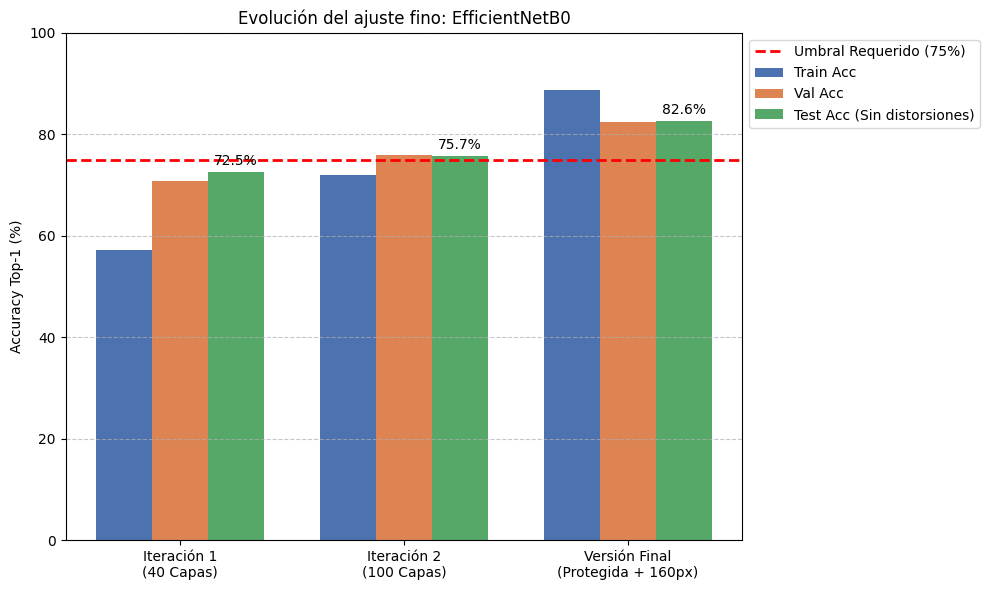

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def obtener_metricas_completas(hist_tl, hist_ft):
    """Extrae el accuracy máximo de entrenamiento y validación de ambos historiales combinados."""
    acc_train = max(max(hist_tl.history['accuracy']), max(hist_ft.history['accuracy'])) * 100
    acc_val = max(max(hist_tl.history['val_accuracy']), max(hist_ft.history['val_accuracy'])) * 100
    return acc_train, acc_val

print("Evaluando exactitud final en prueba para las 3 variantes de EfficientNetB0...")

# 1. Evaluar el modelo 3 en su estado actual (que corresponde al V3 de 100 capas)
_, acc_test_v3 = modelo3.evaluate(test_ds, verbose=0)

# Extraer métricas de los historiales en memoria
acc_tr_v2, acc_val_v2 = obtener_metricas_completas(historial3_tl, historial3_ft_v2)
acc_tr_v3, acc_val_v3 = obtener_metricas_completas(historial3_tl, historial3_ft_v3)
acc_tr_prot, acc_val_prot = obtener_metricas_completas(historial3_tl_protegido, historial3_ft_protegido)

# Armar datos comparativos
datos_eff = [
    {"Versión": "Iteración 1\n(40 Capas)", "Acc. Train": acc_tr_v2, "Acc. Val": acc_val_v2, "Acc. Test": 72.5}, # Reemplaza el 72.5 con el valor real si evaluaste test_acc3_v2 antes
    {"Versión": "Iteración 2\n(100 Capas)", "Acc. Train": acc_tr_v3, "Acc. Val": acc_val_v3, "Acc. Test": acc_test_v3 * 100},
    {"Versión": "Versión Final\n(Protegida + 160px)", "Acc. Train": acc_tr_prot, "Acc. Val": acc_val_prot, "Acc. Test": test_acc3_protegido * 100}
]

df_eff = pd.DataFrame(datos_eff)

def graficar_evolucion_efficientnet(df):
    """Genera gráfica de barras evidenciando el fenómeno de Test > Train."""
    train_acc = df['Acc. Train'].astype(float)
    val_acc = df['Acc. Val'].astype(float)
    test_acc = df['Acc. Test'].astype(float)
    nombres = df['Versión']

    x = np.arange(len(nombres))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    rects1 = ax.bar(x - width, train_acc, width, label='Train Acc', color='#4C72B0')
    rects2 = ax.bar(x, val_acc, width, label='Val Acc', color='#DD8452')
    rects3 = ax.bar(x + width, test_acc, width, label='Test Acc (Sin distorsiones)', color='#55A868')

    ax.axhline(y=75.0, color='r', linestyle='--', linewidth=2, label='Umbral Requerido (75%)')

    ax.set_ylabel('Accuracy Top-1 (%)')
    ax.set_title('Evolución del ajuste fino: EfficientNetB0')
    ax.set_xticks(x)
    ax.set_xticklabels(nombres)
    ax.set_ylim(0, 100)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    ax.bar_label(rects3, padding=3, fmt='%.1f%%')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("EVOLUCIÓN EXPERIMENTAL DE EFFICIENTNET B0")
print("="*70)
print(df_eff.round(2).to_string(index=False))
print("\nGenerando gráfica evolutiva...")
graficar_evolucion_efficientnet(df_eff)

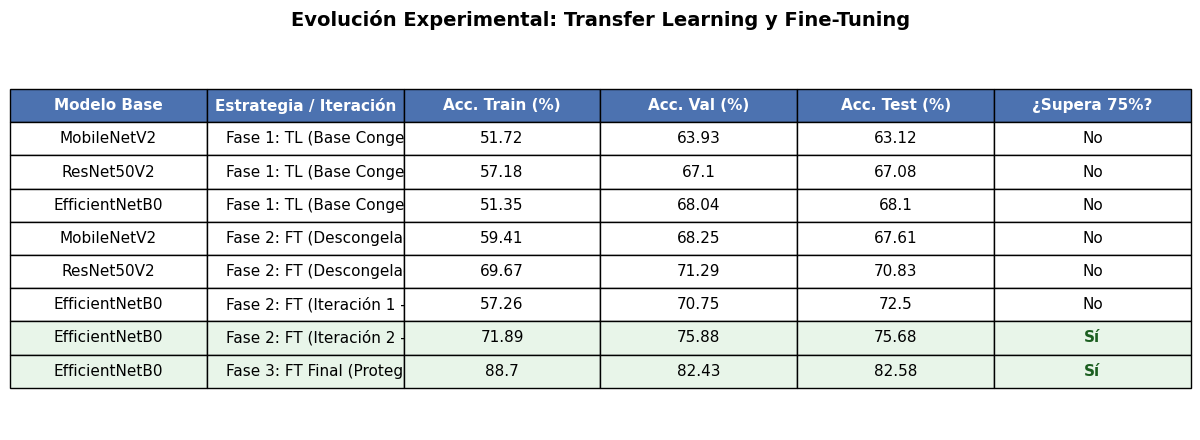

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Recopilación de todos los datos experimentales
datos_evolucion = [
    ["MobileNetV2", "Fase 1: TL (Base Congelada)", 51.72, 63.93, 63.12, "No"],
    ["ResNet50V2", "Fase 1: TL (Base Congelada)", 57.18, 67.10, 67.08, "No"],
    ["EfficientNetB0", "Fase 1: TL (Base Congelada)", 51.35, 68.04, 68.10, "No"],
    ["MobileNetV2", "Fase 2: FT (Descongelado 50 Capas)", 59.41, 68.25, 67.61, "No"],
    ["ResNet50V2", "Fase 2: FT (Descongelado 70 Capas)", 69.67, 71.29, 70.83, "No"],
    ["EfficientNetB0", "Fase 2: FT (Iteración 1 - 40 Capas)", 57.26, 70.75, 72.50, "No"],
    ["EfficientNetB0", "Fase 2: FT (Iteración 2 - 100 Capas)", 71.89, 75.88, 75.68, "Sí"],
    ["EfficientNetB0", "Fase 3: FT Final (Protegida + 160px)", 88.70, 82.43, 82.58, "Sí"]
]

columnas = ["Modelo Base", "Estrategia / Iteración", "Acc. Train (%)", "Acc. Val (%)", "Acc. Test (%)", "¿Supera 75%?"]
df_evolucion = pd.DataFrame(datos_evolucion, columns=columnas)

# 2. Configuración de la figura para la tabla
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axis('tight')
ax.axis('off')

# 3. Dibujar la tabla
tabla = ax.table(cellText=df_evolucion.values,
                 colLabels=df_evolucion.columns,
                 cellLoc='center',
                 loc='center')

# 4. Estilo y formato
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.2, 1.8)

# Colorear la tabla dinámicamente
for (fila, columna), celda in tabla.get_celld().items():
    if fila == 0:
        # Estilo del encabezado
        celda.set_text_props(weight='bold', color='white')
        celda.set_facecolor('#4C72B0')
    else:
        # Alinear a la izquierda la columna de "Estrategia" para que sea más legible
        if columna == 1:
            celda.set_text_props(ha='left')

        # Resaltar en verde claro si la iteración fue exitosa
        texto_celda = str(celda.get_text().get_text())
        if "Sí" in texto_celda or (fila in [7, 8]):
            # Fila 7 y 8 son los casos de éxito de EfficientNet
            celda.set_facecolor('#e8f5e9')
            if columna == 5: # Hacer el "Sí" verde fuerte y negrita
                celda.set_text_props(weight='bold', color='#1b5e20')

# 5. Título y guardado
plt.title("Evolución Experimental: Transfer Learning y Fine-Tuning", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Guardar la imagen en alta resolución
nombre_archivo = 'tabla_evolucion_completa.png'
plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
plt.show()

